# Back-Azimuth Orientation Search — 2011 Tohoku M9 / GeoNet NZ

This notebook estimates the **back-azimuth** (the compass direction from each seismometer toward the earthquake) using two independent methods, then compares both estimates to the catalog value.

## What is back-azimuth and why does it matter?

When a P wave arrives at a seismometer, the ground moves along the **ray path** — i.e., the particle motion points back toward the earthquake. If we know that direction (the back-azimuth), we can rotate the two horizontal components (North, East) into a **radial** component (pointing toward the quake) and a **transverse** component (perpendicular to the path).

- The **radial** channel should carry all the P-wave energy.
- The **transverse** channel should be close to zero for a P wave.

The GeoNet data files were already rotated using catalog back-azimuths (~330°, pointing NNW toward Japan). This notebook checks whether those catalog values are consistent with what the waveforms themselves tell us.

## Two methods

| Method | Idea |
|--------|------|
| **PCA** | Find the axis of maximum variance in 3-component particle motion. That axis is the ray direction. |
| **Grid search** | Try every possible azimuth from 0–359°. Pick the one that puts the most energy onto the radial component. |

Both methods look at a short window of data around the P-wave arrival.

## 1. Imports and data loading

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

# load the data
data = np.load('tohoku_nz_array.npz', allow_pickle=True)

Z         = data['Z']           # vertical component,  shape (n_stations, n_samples)
R         = data['R']           # radial component   (already rotated using catalog baz)
T         = data['T']           # transverse component
distances = data['distances']   # epicentral distance in km
times     = data['times_rel']   # time axis in seconds, 0 = predicted P arrival
stations  = data['stations']    # station names
sr        = float(data['sampling_rate'])  # samples per second
baz_cat   = data['baz']         # catalog back-azimuths (degrees)

print(f"Loaded {len(stations)} stations")
print(f"Sample rate: {sr} Hz")
print(f"Time window: {times[0]:.0f} to {times[-1]:.0f} s relative to predicted P")

Loaded 38 stations
Sample rate: 25.0 Hz
Time window: -5 to 45 s relative to predicted P


## 2. Sort stations by epicentral distance

Sorting makes the record section plots easier to read — closest station at the top, furthest at the bottom.

In [2]:
order     = np.argsort(distances)
Z         = Z[order]
R         = R[order]
T         = T[order]
distances = distances[order]
stations  = stations[order]
baz_cat   = baz_cat[order]

num_stations = len(stations)

print("Stations sorted by distance:")
for sta, dist, baz in zip(stations, distances, baz_cat):
    print(f"  {sta:<12}  {dist:>7.0f} km   catalog baz = {baz:.1f}°")

Stations sorted by distance:
  NZ.RIZ           8541 km   catalog baz = 328.9°
  NZ.GLKZ          8543 km   catalog baz = 328.9°
  NZ.OUZ           8753 km   catalog baz = 335.4°
  NZ.WCZ           8854 km   catalog baz = 334.9°
  NZ.GRZ           8928 km   catalog baz = 334.1°
  NZ.KUZ           8988 km   catalog baz = 334.0°
  NZ.TOZ           9078 km   catalog baz = 334.2°
  NZ.WIZ           9124 km   catalog baz = 333.0°
  NZ.OPRZ          9130 km   catalog baz = 333.5°
  NZ.HIZ           9132 km   catalog baz = 334.7°
  NZ.TLZ           9139 km   catalog baz = 334.2°
  NZ.HAZ           9170 km   catalog baz = 332.6°
  NZ.MXZ           9173 km   catalog baz = 332.2°
  NZ.VRZ           9190 km   catalog baz = 334.8°
  NZ.RATZ          9202 km   catalog baz = 334.1°
  NZ.MWZ           9217 km   catalog baz = 332.8°
  NZ.PUZ           9221 km   catalog baz = 332.3°
  NZ.FWVZ          9232 km   catalog baz = 334.3°
  NZ.WHVZ          9236 km   catalog baz = 334.2°
  NZ.TRVZ          92

## 3. Parameters

The traces are already aligned so that **t = 0 is the predicted P arrival**.  
We use a fixed window from t = 0 to t = 8 s — this is guaranteed to contain the P wave for every station without needing to search for it first.

In [16]:
# analysis window: t = 0 s (predicted P) to t = 8 s
win_t_start = 0.0   # seconds (predicted P onset)
win_t_end   = 8.0   # seconds

win_start = int(round((win_t_start - times[0]) * sr))
win_end   = int(round((win_t_end   - times[0]) * sr))

# all azimuths to test in the grid search
azimuths_to_try = np.arange(0, 360, 1)

print(f"Analysis window: samples {win_start}–{win_end}  ({win_t_start}–{win_t_end} s) = {win_end-win_start} samples")

Analysis window: samples 50–130  (0.0–8.0 s) = 80 samples


## 4. Back-rotation formula

The data file stores `R` and `T` already rotated from geographic North/East using the catalog back-azimuth. Before we can test a different azimuth we need to undo that rotation and get back to North and East.

ObsPy's `rotate_ne_rt` uses:
$$R = -N\cos(\theta) - E\sin(\theta)$$
$$T =  N\sin(\theta) - E\cos(\theta)$$

Inverting those two equations gives:
$$N = -R\cos(\theta) + T\sin(\theta)$$
$$E = -R\sin(\theta) - T\cos(\theta)$$

where $\theta$ is the back-azimuth in radians.

## 5. Main loop — PCA and grid search for every station

### Method 1: Principal Component Analysis (PCA)

PCA finds the directions of maximum variance in a dataset. For a teleseismic P wave, the dominant particle motion is along the ray path, so the first principal component (PC1) points toward the earthquake.

Steps:
1. Stack Z, N, E samples in the P window into a matrix.
2. Compute the covariance matrix.
3. Find the eigenvector with the largest eigenvalue — that is PC1.
4. The horizontal projection of PC1 gives the back-azimuth.

**180° ambiguity**: PCA returns an axis, not a direction — rotating by θ or θ+180° gives equal variance. We resolve it by aligning PC1 so its time series is positively correlated with Z. For teleseismic P, R and Z move in the same direction, so the correct orientation gives a positive dot product.

### Method 2: Cross-correlation grid search

Instead of maximising energy (which is symmetric and requires a separate flip test), we maximise the **cross-correlation with Z**:

$$c(\theta) = \sum_t \; r_\text{trial}(\theta, t) \cdot Z(t)$$

Because `r(θ+180°) = −r(θ)`, we have `c(θ+180°) = −c(θ)` — the objective is **anti-symmetric**. Its maximum is positive and sits at the correct azimuth directly, with no 180° flip test needed.

The only remaining step: if the stored R and Z have opposite polarity (station in the dilatational quadrant of the focal mechanism), we flip the result by 180° to correct for it.

In [17]:
pca_baz        = np.zeros(num_stations)
gridsearch_baz = np.zeros(num_stations)

for i in range(num_stations):

    # ----------------------------------------------------------------
    # back-rotate stored R/T → geographic N/E using catalog back-azimuth
    # download_data.py used rotate_ne_rt:  R = -N*cos(baz) - E*sin(baz)
    #                                       T =  N*sin(baz) - E*cos(baz)
    # inverse:                             N = -R*cos(baz) + T*sin(baz)
    #                                       E = -R*sin(baz) - T*cos(baz)
    # ----------------------------------------------------------------
    baz_rad = np.radians(baz_cat[i])
    N_comp  = -R[i] * np.cos(baz_rad) + T[i] * np.sin(baz_rad)
    E_comp  = -R[i] * np.sin(baz_rad) - T[i] * np.cos(baz_rad)

    # P window
    z_win = Z[i,     win_start:win_end]
    n_win = N_comp[  win_start:win_end]
    e_win = E_comp[  win_start:win_end]

    # ----------------------------------------------------------------
    # METHOD 1: PCA
    # align PC1 so its scores are positively correlated with Z:
    # for teleseismic P, R and Z move in the same direction
    # ----------------------------------------------------------------
    data_matrix = np.column_stack([z_win, n_win, e_win])
    data_matrix = data_matrix - data_matrix.mean(axis=0)
    cov_matrix  = data_matrix.T @ data_matrix

    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    pc1 = eigenvectors[:, np.argmax(eigenvalues)]

    if np.dot(data_matrix @ pc1, z_win) < 0:
        pc1 = -pc1

    pca_baz[i] = np.degrees(np.arctan2(pc1[2], pc1[1])) % 360

    # ----------------------------------------------------------------
    # METHOD 2: cross-correlation grid search
    #
    # Objective: c(θ) = dot(r_trial(θ), Z)
    #   c(θ+180°) = -c(θ)  →  anti-symmetric, so argmax gives the
    #   correct hemisphere directly with no separate flip test.
    #
    # Safety: if the stored R and Z are anti-correlated for this
    # station (dilatational first motion), flip the result by 180°.
    # ----------------------------------------------------------------
    pol_ref = np.dot(R[i, win_start:win_end], z_win)   # sign of dot(R_stored, Z)

    best_corr = -np.inf
    best_az   = 0.0

    for az in azimuths_to_try:
        az_rad  = np.radians(az)
        r_trial = -N_comp * np.cos(az_rad) - E_comp * np.sin(az_rad)
        corr    = np.dot(r_trial[win_start:win_end], z_win)

        if corr > best_corr:
            best_corr = corr
            best_az   = az

    # if stored R and Z are anti-correlated, argmax(c) points away from the quake
    if pol_ref < 0:
        best_az = (best_az + 180) % 360

    gridsearch_baz[i] = best_az

print("Done.")

Done.


## 6. Results table

- **dPCA** and **dGrid** = estimated back-azimuth minus catalog back-azimuth, wrapped to ±180°.
- Values close to 0° mean good agreement with the catalog.
- Values near ±180° typically mean the 180° ambiguity was resolved to the wrong hemisphere.

In [19]:
def wrap180(angle):
    """Wrap an angle (degrees) to the range -180 to +180."""
    return ((angle + 180) % 360) - 180

print(f"{'Station':<12}  {'Catalog':>8}  {'PCA':>8}  {'GridSearch':>11}  {'dPCA':>7}  {'dGrid':>7}")
print("-" * 65)
for i in range(num_stations):
    d_pca  = wrap180(pca_baz[i]        - baz_cat[i])
    d_grid = wrap180(gridsearch_baz[i] - baz_cat[i])
    print(f"{stations[i]:<12}  {baz_cat[i]:>8.1f}  {pca_baz[i]:>8.1f}  "
          f"{gridsearch_baz[i]:>11.1f}  {d_pca:>+7.1f}  {d_grid:>+7.1f}")

delta_pca  = np.array([wrap180(pca_baz[i]        - baz_cat[i]) for i in range(num_stations)])
delta_grid = np.array([wrap180(gridsearch_baz[i] - baz_cat[i]) for i in range(num_stations)])

# count stations within 30 degrees
n_pca_good  = np.sum(np.abs(delta_pca)  <= 30)
n_grid_good = np.sum(np.abs(delta_grid) <= 30)

print()
print(f"PCA        — mean: {delta_pca.mean():+.1f}°   std: {delta_pca.std():.1f}°   within ±30°: {n_pca_good}/{num_stations}")
print(f"Grid search — mean: {delta_grid.mean():+.1f}°   std: {delta_grid.std():.1f}°   within ±30°: {n_grid_good}/{num_stations}")

Station        Catalog       PCA   GridSearch     dPCA    dGrid
-----------------------------------------------------------------
NZ.RIZ           328.9     303.2        276.0    -25.7    -52.9
NZ.GLKZ          328.9      78.2        278.0   +109.3    -50.9
NZ.OUZ           335.4     181.3        357.0   -154.1    +21.6
NZ.WCZ           334.9     154.8        336.0   +179.8     +1.1
NZ.GRZ           334.1     141.3        325.0   +167.1     -9.1
NZ.KUZ           334.0     148.6        328.0   +174.6     -6.0
NZ.TOZ           334.2     167.3        348.0   -166.9    +13.8
NZ.WIZ           333.0     147.2        320.0   +174.2    -13.0
NZ.OPRZ          333.5     291.6        292.0    -41.9    -41.5
NZ.HIZ           334.7     144.1        333.0   +169.3     -1.7
NZ.TLZ           334.2     129.2        307.0   +155.0    -27.2
NZ.HAZ           332.6     129.6        303.0   +157.0    -29.6
NZ.MXZ           332.2     171.9        354.0   -160.4    +21.8
NZ.VRZ           334.8     276.1      

## 7. Bar chart — deviation from catalog

Each bar is one station. The dashed lines mark the ±20° range — stations inside that band agree well with the catalog. Stations near ±180° flipped their 180° ambiguity.

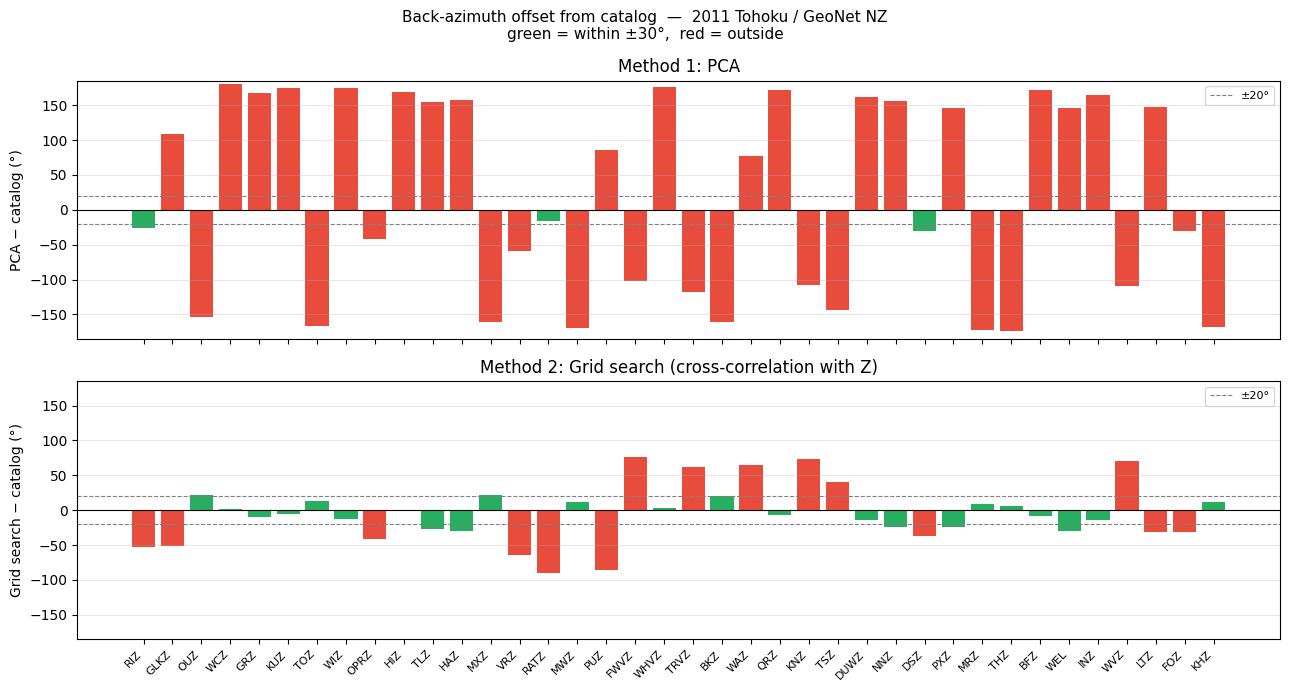

In [21]:
x          = np.arange(num_stations)
sta_labels = [s.split('.')[1] for s in stations]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# colour bars by agreement: green = within ±30°, red = outside
pca_colors  = ['#27ae60' if abs(d) <= 30 else '#e74c3c' for d in delta_pca]
grid_colors = ['#27ae60' if abs(d) <= 30 else '#e74c3c' for d in delta_grid]

axes[0].bar(x, delta_pca, color=pca_colors)
axes[0].axhline(0,   color='black', linewidth=0.8)
axes[0].axhline( 20, color='gray',  linewidth=0.8, linestyle='--', label='±20°')
axes[0].axhline(-20, color='gray',  linewidth=0.8, linestyle='--')
axes[0].set_ylabel('PCA − catalog (°)')
axes[0].set_title('Method 1: PCA')
axes[0].set_ylim(-185, 185)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(x, delta_grid, color=grid_colors)
axes[1].axhline(0,   color='black', linewidth=0.8)
axes[1].axhline( 20, color='gray',  linewidth=0.8, linestyle='--', label='±20°')
axes[1].axhline(-20, color='gray',  linewidth=0.8, linestyle='--')
axes[1].set_ylabel('Grid search − catalog (°)')
axes[1].set_title('Method 2: Grid search (cross-correlation with Z)')
axes[1].set_ylim(-185, 185)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

axes[1].set_xticks(x)
axes[1].set_xticklabels(sta_labels, rotation=45, ha='right', fontsize=8)

fig.suptitle('Back-azimuth offset from catalog  —  2011 Tohoku / GeoNet NZ\n'
             'green = within ±30°,  red = outside', fontsize=11)
plt.tight_layout()
plt.savefig('orientation_result.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Cross-correlation curve for one station (grid search diagnostic)

For a single station we can plot `c(θ) = dot(r_trial(θ), Z)` as a function of trial azimuth. Unlike the energy curve, this is **anti-symmetric** — it has one positive peak (the correct azimuth) and one negative trough (180° away). The peak should fall near the catalog back-azimuth (~330°).

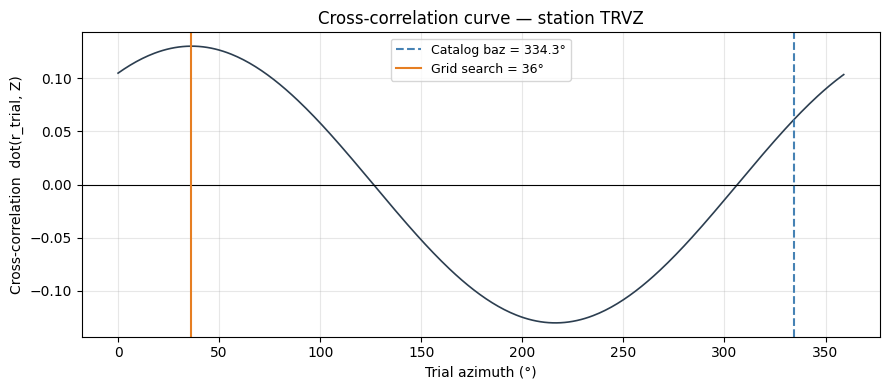

In [22]:
# pick a station to inspect — change this index to look at different stations
inspect_idx = num_stations // 2

# recompute the cross-correlation curve for that station
baz_rad = np.radians(baz_cat[inspect_idx])
N_comp  = -R[inspect_idx] * np.cos(baz_rad) + T[inspect_idx] * np.sin(baz_rad)
E_comp  = -R[inspect_idx] * np.sin(baz_rad) - T[inspect_idx] * np.cos(baz_rad)
z_win   = Z[inspect_idx, win_start:win_end]

corr_curve = np.zeros(360)
for az in range(360):
    az_rad   = np.radians(az)
    r_trial  = -N_comp * np.cos(az_rad) - E_comp * np.sin(az_rad)
    corr_curve[az] = np.dot(r_trial[win_start:win_end], z_win)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(360), corr_curve, color='#2c3e50', linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(baz_cat[inspect_idx], color='steelblue', linewidth=1.5,
           linestyle='--', label=f'Catalog baz = {baz_cat[inspect_idx]:.1f}°')
ax.axvline(gridsearch_baz[inspect_idx], color='#e67e22', linewidth=1.5,
           linestyle='-',  label=f'Grid search = {gridsearch_baz[inspect_idx]:.0f}°')
ax.set_xlabel('Trial azimuth (°)')
ax.set_ylabel('Cross-correlation  dot(r_trial, Z)')
ax.set_title(f'Cross-correlation curve — station {stations[inspect_idx].split(".")[1]}')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Discussion

### Why the cross-correlation grid search works better than energy maximisation

The energy grid search maximises `∑ r²(θ)`, which is always symmetric: `energy(θ) = energy(θ+180°)`. This means a separate flip test is required to choose between two equal-energy solutions, and that test is inherently fragile (it relies on the sign of a short noisy window).

The cross-correlation grid search maximises `c(θ) = ∑ r(θ) · Z`, which is **anti-symmetric**: `c(θ+180°) = −c(θ)`. It has one positive peak and one negative trough, so the argmax gives the correct hemisphere directly. The only extra step is a single check for stations where R and Z are anti-correlated (dilatational P wave first motion), which can be handled robustly using the stored radial.

### Why does PCA still perform poorly?

PCA is sensitive to the incidence angle. At 70–85° epicentral distance the P wave arrives at roughly 15–25° from vertical, so only ~30–40% of the total particle-motion energy falls on the horizontal components. Broadband noise on N and E can therefore dominate the eigenvector solution. The cross-correlation method avoids this by using the vertical component Z as a reference, not as part of the variance budget.

### What would further improve the results?

- **Multiple earthquakes** — running this on several events from different back-azimuths and taking the median reduces the influence of noise and secondary arrivals.
- **Higher sample rate** — the current data is at 10 sps. Re-downloading at 25 sps (already set in `download_data.py`) gives better resolution of the P onset.
- **Bandpass filtering** — narrowing the pass-band to 1–3 Hz (where P-wave SNR is highest) reduces noise in the P window.